Index(['구분/지역명 ◁▷', 'Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3', '총계',
       'Unnamed: 5', '2019년', 'Unnamed: 7', '2020년', 'Unnamed: 9', '2021년',
       'Unnamed: 11', '2022년', 'Unnamed: 13', '2023년', 'Unnamed: 15'],
      dtype='object')
  구분/지역명 ◁▷ Unnamed: 1 Unnamed: 2 Unnamed: 3         총계  Unnamed: 5    2019년  \
0      총이재민        NaN        NaN       세대/명   53915.00     95287.0  3730.00   
1        인명         사망        NaN          명     284.00         NaN    48.00   
2       NaN         실종        NaN          명       8.00         NaN     0.00   
3       NaN         부상        NaN          명     162.00         NaN    37.00   
4       NaN          계        NaN          명     454.00         NaN    85.00   
5        침수        농경지        NaN         ha  140707.90         NaN   214.18   
6       NaN         도시        NaN         ha   18762.53         NaN     0.00   
7       NaN          계        NaN         ha  159470.43         NaN   214.18   
8        건물        주건물      유실·전파          

C:\Users\zkdlt\AppData\Local\Temp\ipykernel_14020\2732492643.py:30: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['분류1'] = df['구분/지역명 ◁▷'].fillna(method='ffill')


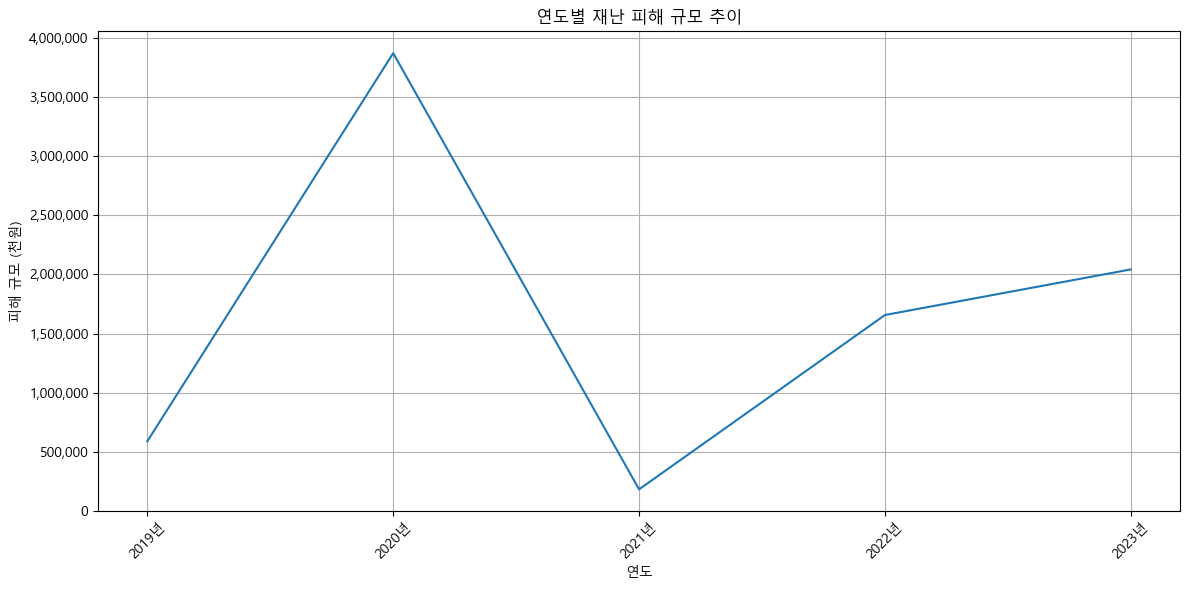

가장 피해가 컸던 해: 2020년년, 피해 규모: 3,869,300,258원
재난유형과 구분 컬럼 추가:
     피해항목     연도     피해규모  재난유형   구분
0   총이재민_  2019년  3730.00  총이재민     
1   인명_사망  2019년    48.00    인명   사망
2   인명_실종  2019년     0.00    인명   실종
3   인명_부상  2019년    37.00    인명   부상
4    인명_계  2019년    85.00    인명    계
5  침수_농경지  2019년   214.18    침수  농경지
6   침수_도시  2019년     0.00    침수   도시
7    침수_계  2019년   214.18    침수    계
8  건물_주건물  2019년    67.00    건물  주건물
9     건물_  2019년   213.00    건물     
피해규모 데이터 타입 확인:
float64
재난 유형별 피해 규모 총합:
        구분          피해규모
0      총합계 5,358,779,141
31   피해액소계 2,622,575,987
30     피해액   298,106,131
2        계    29,336,953
7       답작    19,574,304
25      전작     8,679,321
1       가축     1,864,555
4       기타     1,164,620
22  어망, 어구       202,981
35      해양       200,000
5      농경지       140,708
28   축대·담장        82,023
6        답        37,964
24       전        26,362
9       도시        18,763
13   비닐하우스        16,191
16     소규모         9,314
17     소하천         6,222
15      사방        

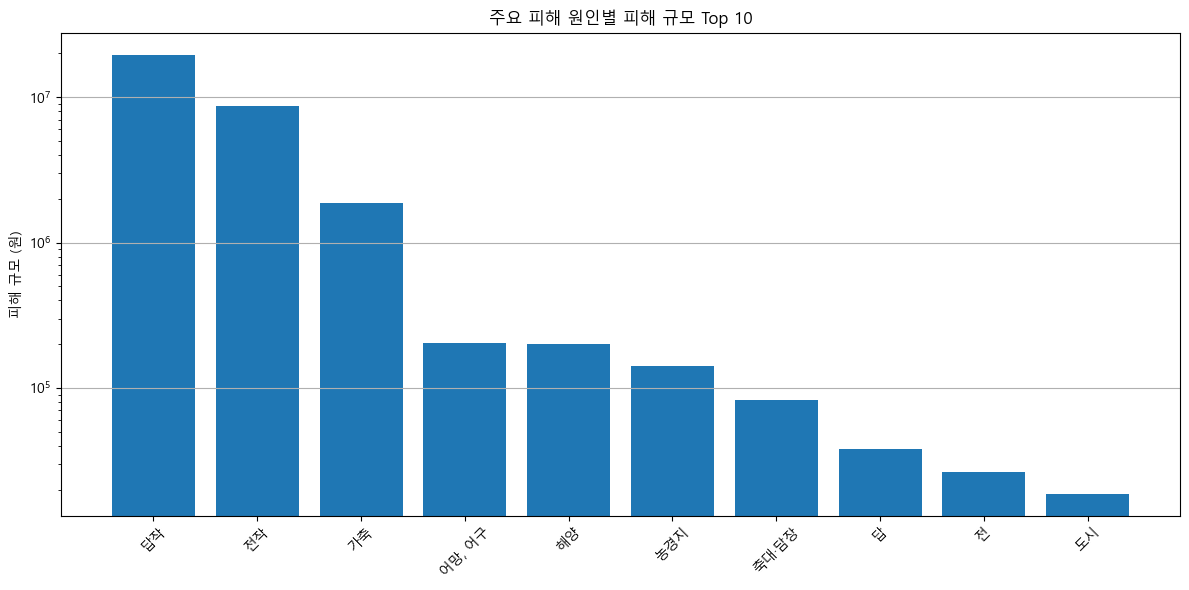

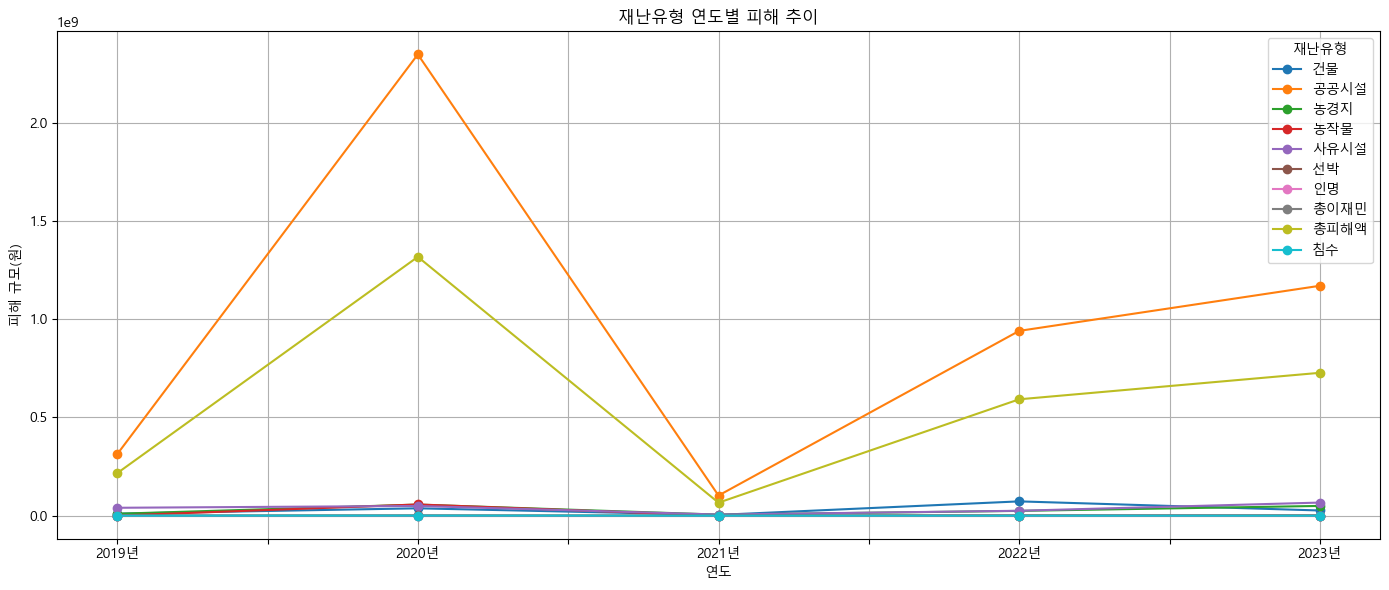

In [1]:
#전국 재난 발생지역 프로젝트
# 전국 재난 발생 지역 EDA: 재난 유형별 피해 지역과 시기 분석

#목표
# 미션 1: 전국적으로 피해 규모가 가장 큰 항목 Top 5
# 미션 2: 연도별 피해 추이 분석
# 미션 3: 피해 원인 분석
# 미션 4: 재난 유형별 연도별 피해 트렌드 분석

import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker  # Y축 단위 형식 지정

# 엑셀 파일 경로
file_path = "C:\\Users\\zkdlt\\Desktop\\프로젝트 과제\\자연재난상황통계.xlsx"
db_path = "C:\\Users\\zkdlt\\Desktop\\프로젝트 과제\\disaster_data.db"

# 필요한 컬럼만 골라서 읽어오기

data = pd.read_excel(file_path)
print(data.columns)
print(data.head(10))

data_cols = ['구분/지역명 ◁▷', 'Unnamed: 1', '2019년', '2020년', '2021년', '2022년', '2023년']
df = data[data_cols].copy()
print(df.head(10))

# 여기서 Nan 값이 있는 행 제거
df['분류1'] = df['구분/지역명 ◁▷'].fillna(method='ffill')
df['분류2'] = df['Unnamed: 1'].fillna('')
df['피해항목'] = df['분류1'] + '_' + df['분류2']

# 필요한 컬럼만 남기고 나머지 컬럼 제거
# melt 형식으로 변환
df_melted = pd.melt(df,
                    id_vars= '피해항목',
                    value_vars=['2019년', '2020년', '2021년', '2022년', '2023년'],
                    var_name='연도',
                    value_name='피해규모'
)
print(df_melted.head(10))

# SQLite 데이터베이스 연결
conn = sqlite3.connect("db_path")

df_melted.to_sql(
    name='disaster_data',
    con=conn,
    index=False,
    if_exists='replace'
)

print("SQLite DB에 저장 완료!")

# 확인용 쿼리 실행
query = "SELECT * FROM disaster_data LIMIT 5;"
sample = pd.read_sql_query(query, conn)
print(sample)

# 데이터베이스 연결 종료
conn.close()

# SQLite 데이터베이스 연결
conn = sqlite3.connect("db_path")

# 미션 1: 전국적으로 피해 규모가 가장 큰 항목 Top 5
query1 = """
SELECT 피해항목, SUM(피해규모) AS 총피해
FROM disaster_data
GROUP BY 피해항목
ORDER BY 총피해 DESC
LIMIT 5;
"""
top5 = pd.read_sql_query(query1, conn)

print("전국적으로 피해 규모가 가장 큰 항목 Top 5:")
print(top5.to_string(formatters={'총피해': '{:,.0f}'.format}))

conn.close()

# 미션 2: 연도별 피해 추이 분석

# 연도별 피해 규모 합계 집계하기 (Python=Pandas) 
# df_melted 에서 '연도' 기준으로 그룹화한 후 피해규모를 합쳐보자

year_data = df_melted.groupby('연도')['피해규모'].sum().reset_index()
year_data['피해규모'] = year_data['피해규모'].astype(float)
print("연도별 피해 규모 합계:")
print(year_data.to_string(formatters={'피해규모': '{:,.0f}'.format}))

# 연도별 추이 시각화 (라인차트)
# 한글폰트 적용
plt.rc('font', family='Malgun Gothic')
plt.figure(figsize=(12, 6))
# 피해규모 나누기
year_data['피해(천원)'] = year_data['피해규모'] / 1000  # 천원 단위로 변환
# 그래프 그리기
plt.plot(year_data['연도'], year_data['피해(천원)'])
plt.title('연도별 재난 피해 규모 추이')
plt.xlabel('연도')
plt.ylabel('피해 규모 (천원)')
plt.xticks(rotation=45)
# y축 천 단위 콤마 포맷
ax = plt.gca()
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.grid()
plt.tight_layout()
plt.show()


# 가장 피해가 컸던 해 찾기
max_year = year_data.loc[year_data['피해규모'].idxmax()]
print(f"가장 피해가 컸던 해: {max_year['연도']}년, 피해 규모: {max_year['피해규모']:,.0f}원")

# "피해항목" 에서 재난 유형 분리
df_melted[['재난유형', '구분']] = df_melted['피해항목'].str.split('_', expand=True)
print("재난유형과 구분 컬럼 추가:")
print(df_melted.head(10))

# 피해규모 숫자 타입 확인 및 정제
df_melted['피해규모'] = pd.to_numeric(df_melted['피해규모'], errors='coerce')
# NaN 값 제거
df_melted = df_melted.dropna(subset=['피해규모'])   
print("피해규모 데이터 타입 확인:")
print(df_melted['피해규모'].dtype)

# 그룹화해서 재난 유형별 피해 총합 구하고 내림차순 정렬
df_by_type = df_melted.groupby('구분')['피해규모'].sum().reset_index()
df_by_type = df_by_type.sort_values(by='피해규모', ascending=False)
df_by_type['구분'] = df_by_type['구분'].replace('', '총합계')

print("재난 유형별 피해 규모 총합:")
print(df_by_type.to_string(formatters={'피해규모': '{:,.0f}'.format}))
# 합계 계열 제거
drop_list = ['계', '피해액', '피해액소계', '총합계', '기타']
# 해당 값들 제외한 데이터 프레임 재정의
df_by_type = df_by_type[~df_by_type['구분'].isin(drop_list)]
# 피해 규모 내림차순 정렬
df_by_type = df_by_type.sort_values(by='피해규모', ascending=False)
print((df_by_type.to_string(formatters={'피해규모': '{:,.0f}'.format})))

# 재난 유형별 피해 규모 시각화(상위 10개)
top10 = df_by_type.head(10)


plt.figure(figsize=(12, 6))
plt.bar(top10['구분'], top10['피해규모'])
plt.yscale('log')  # 로그 스케일로 Y축 설정
plt.xticks(rotation=45)
plt.title('주요 피해 원인별 피해 규모 Top 10')
plt.ylabel('피해 규모 (원)')
plt.tight_layout()
plt.grid(axis='y')
plt.show()

# 미션 4: 재난 유형별 연도별 피해 트렌드 분석

df_trend = df_melted.groupby(['재난유형', '연도'], as_index=False)['피해규모'].sum()


# 재난유형별로 나누어서 선 그래프로 그리기

pivot = df_trend.pivot(index='연도', columns='재난유형', values='피해규모')
pivot.plot(figsize=(14,6), marker='o')
plt.title("재난유형 연도별 피해 추이")
plt.ylabel("피해 규모(원)")
plt.grid(True)
plt.legend(title='재난유형')
plt.tight_layout()
plt.show()
